# Importing FMUs for Co-Simulation


## Overview

In this tutorial we load a prebuilt FMU and run a simple pendulum simulation. The focus is on the `FMUComponent` interface and the simulation workflow. An optional advanced section shows how to rebuild the FMU from the provided Modelica model using OpenModelica.


## Learning Goals

- Load a prebuilt FMU and instantiate an `FMUComponent`
- Perform a minimal FMU inspection (inputs and outputs)
- Run a free swing simulation and a simulation with external torque


## Prerequisites and Setup

- You have installed `syssimx` and its Python dependencies
- You have `numpy`, `matplotlib`, and `fmpy` available
- You are comfortable running Jupyter Notebook cells

Optional (advanced section only):
- OpenModelica and `OMPython`


In [1]:
import sys
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

from fmpy import read_model_description
from syssimx import FMUComponent

## Beginner Path: Use the Prebuilt FMU

The prebuilt FMU is shipped with the tutorial materials. We look for it in the notebook folder and fall back to the repository path if needed.


In [2]:
# get the system (WINDOWS/LINUX)
platform = sys.platform

fmu_path = Path.cwd() / f'docs/03_core_tutorials/01_fundamentals/Pendulum_{platform}.fmu'
fmu_path = fmu_path.resolve()
if not fmu_path.exists():
    raise FileNotFoundError(f"FMU not found: {fmu_path}")
print(f"Using FMU at: {fmu_path}")

Using FMU at: /home/flo/code/SystemSimulation/docs/03_core_tutorials/01_fundamentals/Pendulum_linux.fmu


## Minimal FMU Inspection

We can inspect the model name and the input/output variables.
You can explore the model description further on your own by printing the attributes of the `ModelDescription` object returned by `read_model_description(fmu_path)`.

In [3]:
model_description = read_model_description(fmu_path)
print(f"Model: {model_description.modelName}")

inputs = [v for v in model_description.modelVariables if v.causality == "input"]
outputs = [v for v in model_description.modelVariables if v.causality == "output"]

def format_var(v):
    unit = getattr(v, "unit", None) or "-"
    return f"{v.name} ({unit})"

print("Inputs:")
for v in inputs:
    print("-", format_var(v))

print("Outputs:")
for v in outputs:
    print("-", format_var(v))


Model: SimplePendulum
Inputs:
- torque (N.m)
Outputs:
- alpha (rad/s2)
- omega (rad/s)
- q (rad)


## Instantiate the FMUComponent


The `FMUComponent` object is instantiated by providing the FMU file path and a name for the component instance.

In [4]:
pendulum = FMUComponent(name="Pendulum", fmu_path=fmu_path)

## Simulation Setup


In [5]:
t0 = 0.0
tf = 5.0
dt = 0.01
time_points = np.arange(t0, tf, dt)

### Free Swing

We run the FMU with zero torque input to simulate a free swing of the pendulum.


In [6]:
pendulum.reset()
pendulum.set_parameters(q0=0.3)
pendulum.initialize(t0=t0)

for t in time_points:
    pendulum.set_inputs({"torque": 0.0}, t=t)
    pendulum.do_step(t, dt)

free_swing_history = pendulum.get_history()

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


We can identify the `LOG_SOLVER` outputs from the FMU instance and see that the FMU uses intenally the solver `CVODE` which is a linear multistep solver.

In [7]:
history = free_swing_history

times = history["q"]['time']
thetas = history["q"]['values']
omegas = history["omega"]['values']
alphas = history["alpha"]['values']

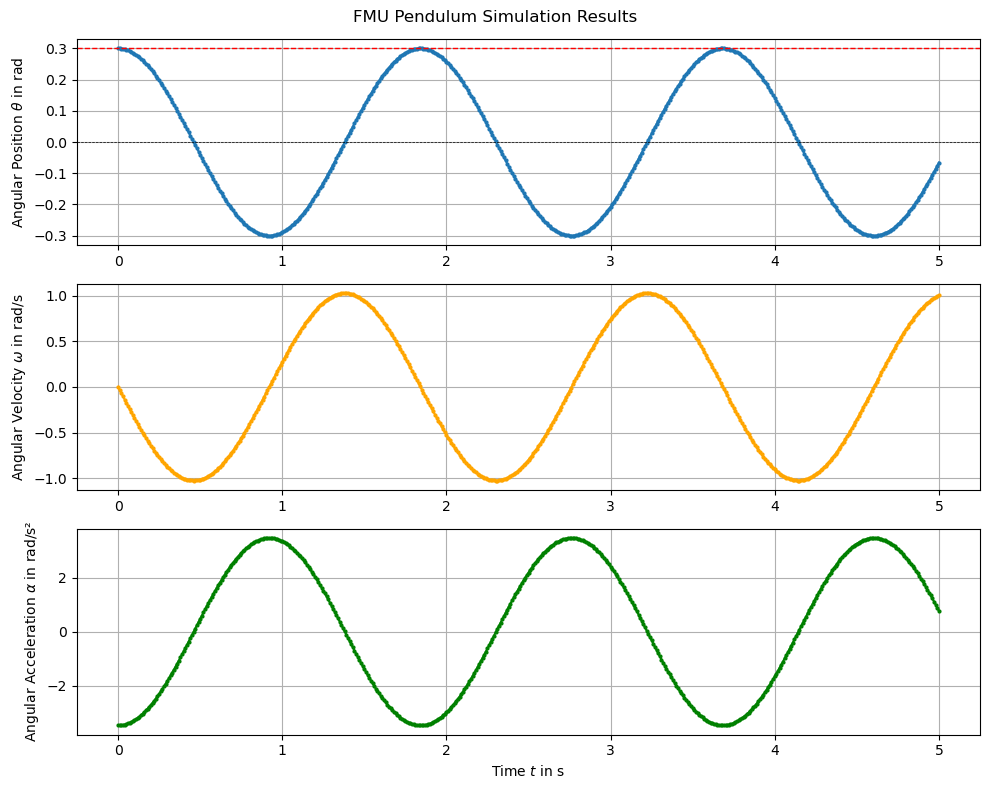

In [8]:
style = {'marker': 'o', 'markersize': 2, 'linestyle': '-'}
plt.figure(figsize=(10, 8))
plt.suptitle("FMU Pendulum Simulation Results")
plt.subplot(3, 1, 1)
plt.plot(times, thetas, **style)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"], color='red', linewidth=1, linestyle='--', label='Initial Angle')
plt.grid()
plt.ylabel(r'Angular Position $\theta$ in rad')

plt.subplot(3, 1, 2)
plt.plot(times, omegas, color='orange', **style)
plt.grid()
plt.ylabel(r'Angular Velocity $\omega$ in rad/s')

plt.subplot(3, 1, 3)
plt.plot(times, alphas, color='green', **style)
plt.grid()
plt.ylabel(r'Angular Acceleration $\alpha$ in rad/s²')
plt.xlabel(r'Time $t$ in s')

plt.tight_layout()
plt.show()

We can observe a typical free swing behavior of the pendulum. The energy is conserved, and the pendulum oscillates indefinitely.

### With External Torque

In this simulation scenario, the pendulum starts from rest, and we apply a small torque step after 1 second to show how inputs affect the FMU.

In [9]:
def torque_input(t):
    return 1 if t >= 1.0 else 0.0

pendulum.reset()
pendulum.set_parameters(q0=0.0)
pendulum.initialize(t0=t0)

for t in time_points:
    pendulum.set_inputs({"torque": torque_input(t)}, t=t)
    pendulum.do_step(t, dt)

forced_history = pendulum.get_history()


LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF


In [10]:
history = forced_history

times = history["q"]['time']
thetas = history["q"]['values']
omegas = history["omega"]['values']
alphas = history["alpha"]['values']

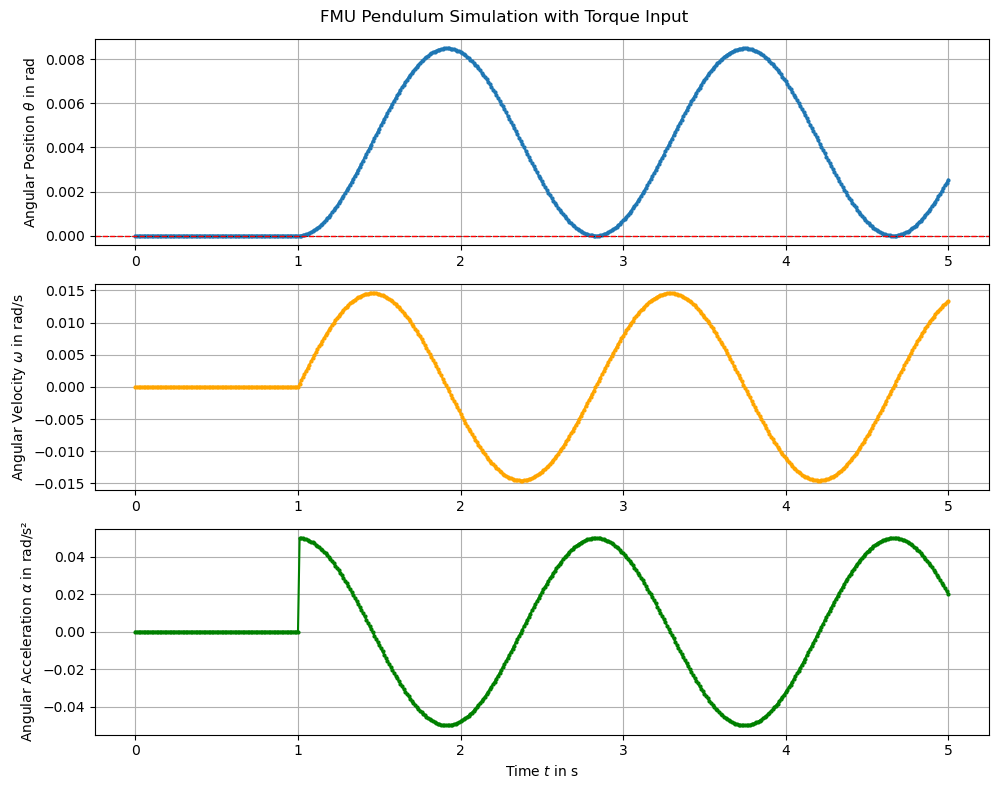

In [11]:
style = {'marker': 'o', 'markersize': 2, 'linestyle': '-'}

plt.figure(figsize=(10, 8))
plt.suptitle("FMU Pendulum Simulation with Torque Input")
plt.subplot(3, 1, 1)
plt.plot(times, thetas, **style)
plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"], color='red', linewidth=1, linestyle='--', label='Initial Angle')
plt.grid()
plt.ylabel(r'Angular Position $\theta$ in rad')

plt.subplot(3, 1, 2)
plt.plot(times, omegas, color='orange', **style)
plt.grid()
plt.ylabel(r'Angular Velocity $\omega$ in rad/s')

plt.subplot(3, 1, 3)
plt.plot(times, alphas, color='green', **style)
plt.grid()
plt.ylabel(r'Angular Acceleration $\alpha$ in rad/s²')
plt.xlabel(r'Time $t$ in s')

plt.tight_layout()
plt.show()

It can be seen that the angular acceleration sees a jump when the torque is applied and the pendulum starts to swing.

## Comparing Parameter Configurations

In [12]:
pendulum.reset()
default_config = pendulum.get_parameters()
print("Default Parameters:")
for k, v in default_config.items():
    print(f" - {k}: {v}")

Default Parameters:
 - L: 0.6 m
 - g: 9.81 m/s²
 - inertia: 20.0 kg·m²
 - m: 40.0 kg
 - omega0: 0.0 rad/s
 - q0: 0.0 rad


In [13]:
pendulum.reset()

default_config = pendulum.get_parameters()

config1 = {
    'L': 2 * default_config['L'],
    'm': 2 * default_config['m'],
}

config2 = {
    'L': 0.5 * default_config['L'],
    'm': 0.5 * default_config['m']
}

labels = ['Default', 'Config 1 -  $2L, 2m$', 'Config 2 - $L/2, m/2$']
configs = [default_config, config1, config2]
histories = []

In [14]:
for i, config in enumerate(configs):
    pendulum.reset()
    pendulum.set_parameters(**config)

    pendulum.initialize(t0=0.0)
    for t in time_points:
        pendulum.set_inputs({'torque': torque_input(t)}, t=t)
        pendulum.do_step(t, dt)

    histories.append(pendulum.get_history())

LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_SOLVER        | info    | CVODE maximum integration order CV_ITER_NEWTON
LOG_SOLVER        | info    | CVODE use equidistant time grid YES
LOG_SOLVER        | info    | CVODE Using relative error tolerance 1.000000e-06
LOG_SOLVER        | info    | CVODE Using dense internal linear solver SUNLinSol_Dense.
LOG_SOLVER        | info    | CVODE Use internal dense numeric jacobian method.
LOG_SOLVER        | info    | CVODE uses internal root finding method NO
LOG_SOLVER        | info    | CVODE maximum absolut step size 0
LOG_SOLVER        | info    | CVODE initial step size is set automatically
LOG_SOLVER        | info    | CVODE maximum integration order 5
LOG_SOLVER        | info    | CVODE maximum number of nonlinear convergence failures permitted during one step 10
LOG_SOLVER        | info    | CVODE BDF stability limit detection algorithm OFF
LOG_SOLVER        | info    | CVODE linear multistep method CV_BDF
LOG_S

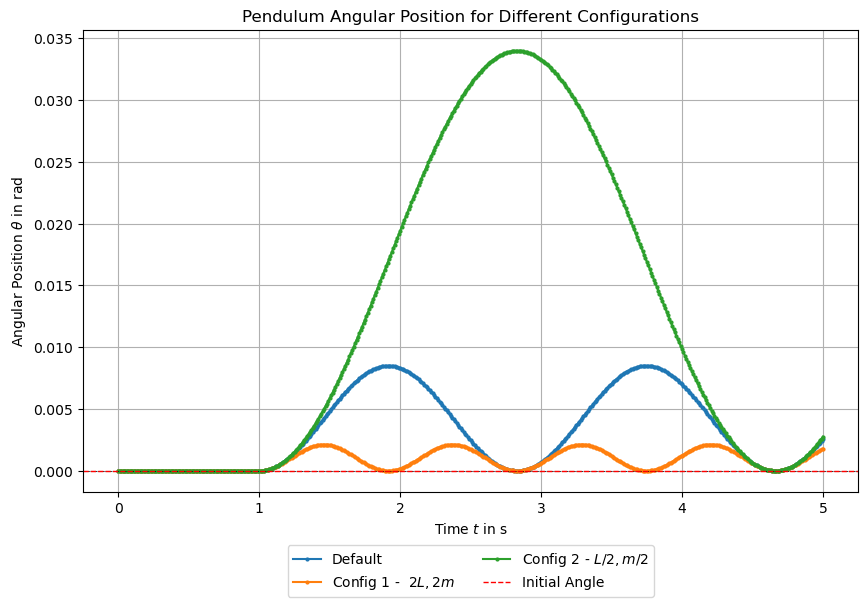

In [15]:
plt.figure(figsize=(10, 6))

for i, history in enumerate(histories):
    times = history["q"]['time']
    thetas = history["q"]['values']
    plt.plot(times, thetas, label=labels[i], **style)

plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
plt.axhline(pendulum.parameters["q0"], color='red', linewidth=1, linestyle='--', label='Initial Angle')

plt.title('Pendulum Angular Position for Different Configurations')
plt.xlabel(r'Time $t$ in s')
plt.ylabel(r'Angular Position $\theta$ in rad')
plt.legend(loc='upper center', bbox_to_anchor=(0.5, -0.1), ncol=2)
plt.grid()

## Advanced: Build the FMU from Modelica (Optional)

If you want to regenerate the FMU yourself, use OpenModelica and OMPython.

The Modelica model looks as follows:

```Modelica
model Pendulum  
  // Imports
  import Modelica.Constants.pi;

  // Parameters
  parameter Real m(unit="kg") = 40;
  parameter Real L(unit="m") = 0.6;
  parameter Real q0(unit="rad") = 0;
  parameter Real omega0(unit="rad/s") = 0;
  parameter Real g(unit="m/s2") = 9.81;
  parameter Real inertia(unit="kg.m2") = 20;
  // Input torque at the pivot
  Modelica.Blocks.Interfaces.RealInput torque(unit="N.m");

  // Outputs
  Modelica.Blocks.Interfaces.RealOutput q(unit="rad");
  Modelica.Blocks.Interfaces.RealOutput omega(unit="rad/s");
  Modelica.Blocks.Interfaces.RealOutput alpha(unit="rad/s2") = der(omega);

initial equation
  q = q0;
  omega = omega0;

equation
  der(q)    = omega;
  der(omega) = -(m * g * L / inertia) * sin(q) + torque / inertia;
end Pendulum;


In [17]:
from OMPython import ModelicaSystem

model_path = Path("Pendulum.mo")
if not model_path.exists():
    model_path = Path("docs/03_core_tutorials/01_fundamentals/Pendulum.mo")

model_path = model_path.resolve()
modelica_system = ModelicaSystem(
    fileName=str(model_path),
    modelName="Pendulum",
    commandLineOptions=["--fmiFlags=s:cvode"],
)
modelica_system.buildModel()
new_fmu_path = modelica_system.convertMo2Fmu(version="2.0", fmuType="cs")
print(f"Generated FMU: {new_fmu_path}")

Generated FMU: /tmp/tmpt0dljb3g/Pendulum.fmu


The FMU is saved at a temporary location.

We can load the `modelDescription.xml` from the FMU and inspect the model name and the input/output variables.

In [18]:
model_description = read_model_description(new_fmu_path)
print(f"Model: {model_description.modelName}")

parameters = [v for v in model_description.modelVariables if v.causality == "parameter"]
print("Parameters:")
for v in parameters:
    print("-", format_var(v))

Model: Pendulum
Parameters:
- L (m)
- g (m/s2)
- inertia (kg.m2)
- m (kg)
- omega0 (rad/s)
- q0 (rad)


In [19]:
inputs = [v for v in model_description.modelVariables if v.causality == "input"]
outputs = [v for v in model_description.modelVariables if v.causality == "output"]

print("Inputs:")
for v in inputs:
    print("-", format_var(v))

print("Outputs:")
for v in outputs:
    print("-", format_var(v))

Inputs:
- torque (N.m)
Outputs:
- alpha (rad/s2)
- omega (rad/s)
- q (rad)


## Summary and Next Steps

You loaded a prebuilt FMU, inspected its interface, and ran two simple simulations. This sets the stage for integrating FMUs into larger systems in the next tutorial.
